In [112]:
import math
import torch
import time
from tqdm import tqdm

dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(dtype)
torch.set_default_device(device)

epoch = 10000
learning_rate = 0.001
update_time = 0.1
max_power = 3

x = torch.linspace(-math.pi, math.pi, 10000)
y = torch.sin(x)

p = torch.tensor(range(1,max_power+1))
xx = x.unsqueeze(-1).pow(p)

model = torch.nn.Sequential(
    torch.nn.Linear(max_power, 1),
    torch.nn.Flatten(0,1),
)

loss_fn = torch.nn.MSELoss()

update_next = time.time()

with tqdm(total=epoch) as pbar:
    for t in range(1, epoch+1):

        y_pred = model(xx)

        loss = loss_fn(y_pred, y)

        if t % 100 == 0:
            pbar.set_postfix(loss=loss.item())
            pbar.update(100)

        # 卧槽居然是忘了这个
        model.zero_grad()

        loss.backward()

        with torch.no_grad():
            for param in model.parameters():
                param -= learning_rate * param.grad

msg = f'y = {model[0].bias.item():.4f}'
for p, w in enumerate(model[0].weight.tolist()[0],start=1):
    msg += f' + {w:.4f} x^{p}'
print(msg)

100%|██████████| 10000/10000 [00:02<00:00, 4625.54it/s, loss=0.00439]

y = -0.0001 + 0.8569 x^1 + 0.0000 x^2 + -0.0934 x^3


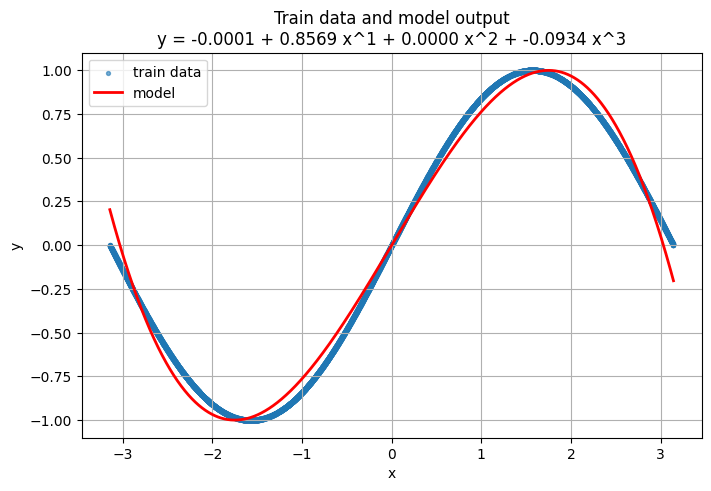

In [113]:
import matplotlib.pyplot as plt

y_plot = model(xx)
y_plot_np = y_plot.cpu().detach().numpy()

# Move tensors to CPU numpy arrays for plotting
x_np = x.cpu().numpy() if x.device.type != 'cpu' else x.numpy()
y_np = y.cpu().numpy() if y.device.type != 'cpu' else y.numpy()

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_np, y_np, s=8, alpha=0.6, label='train data')
plt.plot(x_np, y_plot_np, color='red', linewidth=2, label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.title(
    f"Train data and model output\n"
    f"{msg}"
)
plt.legend()
plt.grid(True)
plt.show()